#### T4 Download the data set customer_data from Canvas. 
The data set contains 
200 records about the age, gender, spending score and annual income of customers that
visit a mall. First, work with two features only, annual income and spending score.

 - a) Visualise the data and try to identify the number of clusters within the data.
 - b) Use the K-Means and Mean Shift algorithms on the data.
 - c) Analyse the results:
     - What can you say about each cluster?
     - If you were the mall manager which cluster would you target adverts at?
 - d) Now work with three features of the data, include the age of customers. Visualise the result of the clustering on a 3D plot

#### Task 4
This is a classic customer segmentation problem, sometimes called the Mall Customer Segmentation Analysis. You’ve got all the right data, and your task (T4) is to explore and cluster the customers based on income, spending behavior, and optionally age.

In [1]:
# --- IMPORT LIBRARIES ---
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib.colors import Normalize
from sklearn.cluster import KMeans, MeanShift

   CustomerID  Gender  Age  Annual Income (k$)  Spending Score (1-100)
0           1    Male   19                  15                      39
1           2    Male   21                  15                      81
2           3  Female   20                  16                       6
3           4  Female   23                  16                      77
4           5  Female   31                  17                      40 



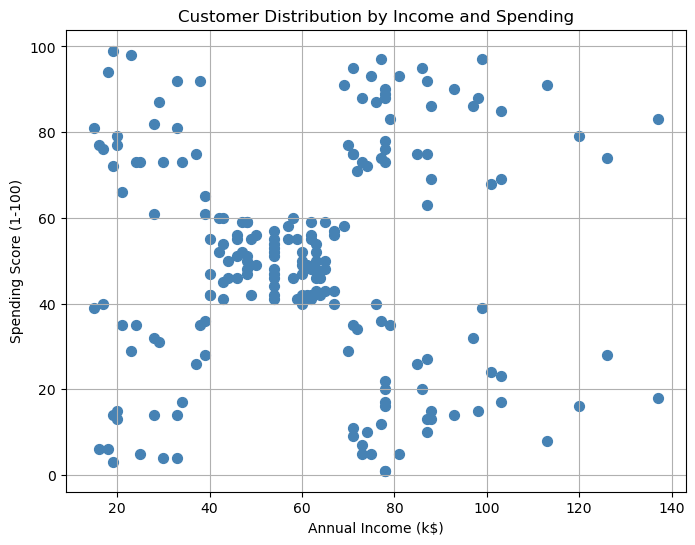

In [2]:
# --- READ THE DATA ---
df = pd.read_csv('customer_data.csv')
print(df.head(), '\n')

# --- SELECT FEATURES ---
X = df.iloc[:, [3, 4]].values  # columns: Annual Income, Spending Score

# --- VISUALIZE THE DATA ---
plt.figure(figsize=(8,6))
plt.scatter(X[:,0], X[:,1], s=50, color='steelblue')
plt.title('Customer Distribution by Income and Spending')
plt.xlabel('Annual Income (k$)')
plt.ylabel('Spending Score (1-100)')
plt.grid(True)
plt.show()

#### Interpretation:
- You'll likely see five clear clusters — one in each corner and one in the center.
- This visual hint helps decide how many clusters to use for K-Means.

### Part (b): Apply Clustering Algorithms

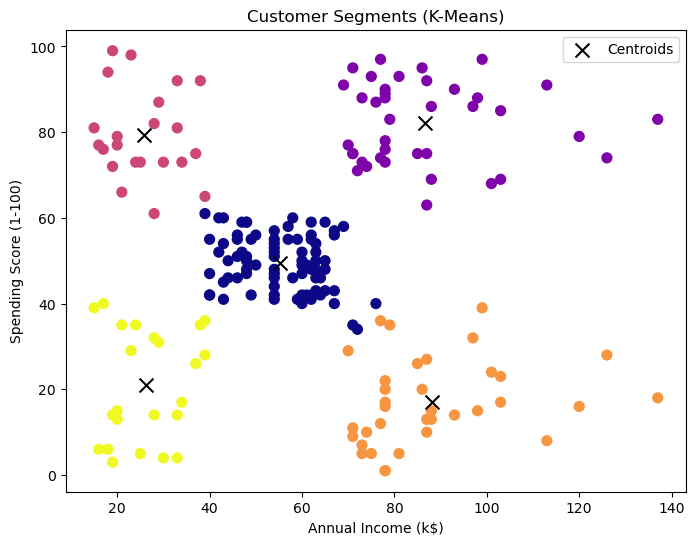

In [4]:
# --- KMeans CLUSTERING ---
kmeans = KMeans(n_clusters=5, n_init='auto', random_state=42)
kmeans.fit(X)
y_kmeans = kmeans.predict(X)

# --- VISUALIZE KMEANS RESULT ---
plt.figure(figsize=(8,6))
plt.scatter(X[:,0], X[:,1], c=y_kmeans, s=50, cmap='plasma')
plt.scatter(kmeans.cluster_centers_[:,0], kmeans.cluster_centers_[:,1],
            s=100, c='black', marker='x', label='Centroids')
plt.title('Customer Segments (K-Means)')
plt.xlabel('Annual Income (k$)')
plt.ylabel('Spending Score (1-100)')
plt.legend()
plt.show()

#### Mean Shift Clustering

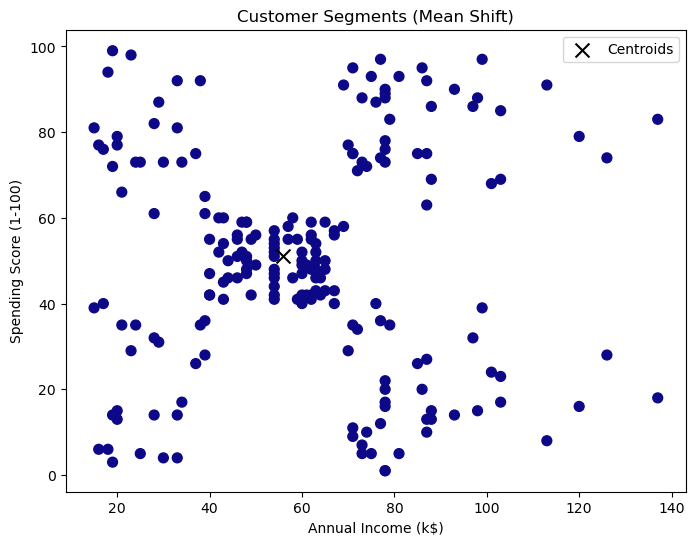

MeanShift found 1 clusters.


In [6]:
# --- MEAN SHIFT CLUSTERING ---
ms = MeanShift()
ms.fit(X)
y_ms = ms.labels_
centers_ms = ms.cluster_centers_

# --- VISUALIZE MEAN SHIFT RESULT ---
plt.figure(figsize=(8,6))
plt.scatter(X[:,0], X[:,1], c=y_ms, s=50, cmap='plasma')
plt.scatter(centers_ms[:,0], centers_ms[:,1],
            s=100, c='black', marker='x', label='Centroids')
plt.title('Customer Segments (Mean Shift)')
plt.xlabel('Annual Income (k$)')
plt.ylabel('Spending Score (1-100)')
plt.legend()
plt.show()

print(f"MeanShift found {len(np.unique(y_ms))} clusters.")

#### Part (d): 3D Clustering (Include Age)

In [7]:
from mpl_toolkits.mplot3d import Axes3D

# --- SELECT THREE FEATURES ---
X3 = df.iloc[:, [2, 3, 4]].values  # Age, Income, Spending Score

In [8]:
# --- KMEANS IN 3D ---
kmeans_3d = KMeans(n_clusters=5, n_init='auto', random_state=42)
kmeans_3d.fit(X3)
y_k3d = kmeans_3d.predict(X3)
centers_3d = kmeans_3d.cluster_centers_

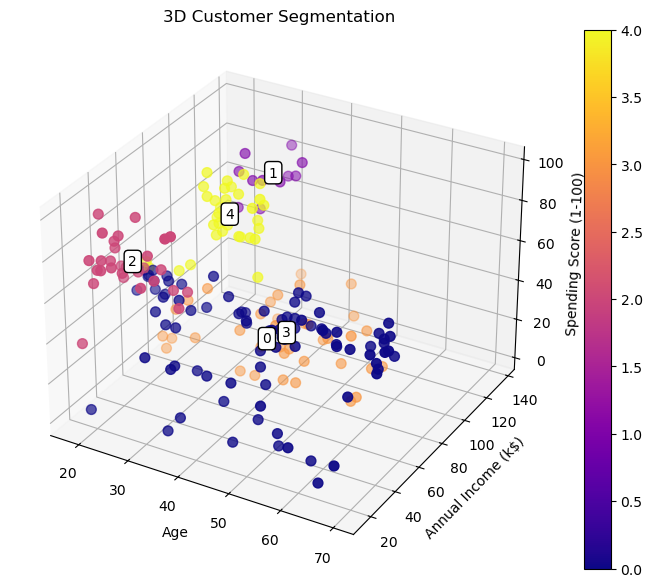

In [15]:
# --- PLOT 3D CLUSTERS ---
fig = plt.figure(figsize=(9,7))
ax = fig.add_subplot(111, projection='3d')

nm = Normalize(vmin=0, vmax=len(centers_3d)-1)
sc = ax.scatter(X3[:,0], X3[:,1], X3[:,2],
                c=y_k3d, s=50, cmap='plasma', norm=nm)

# Label centroids
for i in range(centers_3d.shape[0]):
    ax.text(centers_3d[i,0], centers_3d[i,1], centers_3d[i,2],
            str(i), c='black', bbox=dict(boxstyle="round", facecolor='white', edgecolor='black'))

ax.set_xlabel('Age')
ax.set_ylabel('Annual Income (k$)')
ax.set_zlabel('Spending Score (1-100)')
ax.set_title('3D Customer Segmentation')
fig.colorbar(sc, ax=ax)
plt.show()